In [71]:
from Classes.Grid import Grid
from Classes.ScalarCoeffs import ScalarCoeffs
from Classes.BoundaryConditions import BoundaryLocation, DirichletBc, NeumannBc, RobinBc
from Classes.Models import DiffusionModel, SurfaceConvectionModel
from Classes.LinearSolver import solve

import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt

In [73]:
class FirstOrderTransientModel:
    """Class defining a first order implicit transient model"""

    def __init__(self, grid, T, Told, rho, cp, dt):
        """Constructor"""
        self._grid = grid
        self._T = T
        self._Told = Told
        self._rho = rho
        self._cp = cp
        self._dt = dt

    def add(self, coeffs):
        """Function to add transient term to coefficient arrays"""

        # Calculate the transient term
        rp_coeff = (self._rho * self._cp * self._grid.vol/ self._dt) * (self._T[1:-1] - self._Told[1:-1])

        # Calculate the linearization coefficient
        ap_coeff = (self._rho * self._cp * self._grid.vol/ dt)
        
        # Add to coefficient arrays
        coeffs.accumulate_aP(ap_coeff)
        coeffs.accumulate_rP(rp_coeff)
        
        return coeffs

In [75]:
class SecondOrderTransientModel:
    """Class defining a second order implicit transient model"""

    def __init__(self, grid, T, Told, Told2, rho, cp, dt):
        """Constructor"""
        self._grid = grid
        self._T = T
        self._Told = Told
        self._Told2 = Told2
        self._rho = rho
        self._cp = cp
        self._dt = dt

    def add(self, coeffs):
        """Function to add transient term to coefficient arrays"""
        
        # Calculate the transient term rhp * cp * V *(3T - 4Told + T^Told2) / (2 dt)
        rp_coeff = self._rho * self._cp * self._grid.vol * (3.0 * self._T[1:-1] - 4.0 * self._Told[1:-1] + self._Told2[1:-1]) / (2.0 * self._dt)

        # Calculate the linearization coefficient 3 rho cp V / (2 dt)
        ap_coeff = 3.0 * self._rho * self._cp * self._grid.vol / (2.0 * self._dt)
        
        # Add to coefficient arrays
        coeffs.accumulate_aP(ap_coeff)
        coeffs.accumulate_rP(rp_coeff)
        
        return coeffs

In [85]:
#Parameters

Bi = 1

Ti = 100 #C
To = 0    #C

C1 = 1.1191
zeta = 0.8603

tau1 = 0.4535
tau2 = 3.2632



# Define the grid
lx = 1.0
ly = 0.1
lz = 0.1
ncv = 100
grid = Grid(lx, ly, lz, ncv)

# Set the timestep information
nTime = 8
time = 0
dt = (tau2 - tau1) / nTime

# Set the maximum number of iterations and convergence criterion
maxIter = 10
converged = 1e-6

# Define thermophysical properties
rho = 1
cp = 1
k = 1

h = Bi * k / lx

def analytical_T(x, tau):
    return To + (Ti - To) * C1 * np.exp(-zeta**2 * tau) * np.cos(zeta * x)



# Define the coefficients
coeffs = ScalarCoeffs(grid.ncv)

# Initial conditions
#T0 = 300

# Initialize field variable arrays
T = analytical_T(grid.xP, tau1)

# Define boundary conditions
west_bc = NeumannBc(T, grid, 0.0, BoundaryLocation.WEST)
east_bc = RobinBc(T, grid, h, k, To, BoundaryLocation.EAST)

# Apply boundary conditions
west_bc.apply()
east_bc.apply()

# Create list to store the solutions at each timestep
# Note: If there are a lot of timesteps, this will cost a
#       lot of memory. It is suggested to set a parameter to 
#       only store the solution every N timesteps.
T_solns = [np.copy(T)]

# Define the transient model
Told = np.copy(T)

transient = FirstOrderTransientModel(grid, T, Told, rho, cp, dt)

# Define the diffusion model
diffusion = DiffusionModel(grid, T, k, west_bc, east_bc)

time = tau1
# Define the surface convection model
#surfaceConvection = SurfaceConvectionModel(grid, T, ho, To)

# Loop through all timesteps
for tStep in range(nTime):
    # Update the time information
    time += dt
    
    # Print the timestep information
    print("Timestep = {}; Time = {}".format(tStep, time))
    
    # Store the "old" temperature field
    # Note: do not use copy here because that creates a new object
    #       and we want the reference in the transient model to remain
    #       valid
    Told[:] = T[:]
    
    # Iterate until the solution is converged
    for i in range(maxIter):
        # Zero the coefficients and add each influence
        coeffs.zero()
        coeffs = diffusion.add(coeffs)
        #coeffs = surfaceConvection.add(coeffs)
        coeffs = transient.add(coeffs)
        
        # Compute residual and check for convergence 
        maxResid = norm(coeffs.rP, np.inf)
        avgResid = np.mean(np.absolute(coeffs.rP))
        print("Iteration = {}; Max. Resid. = {}; Avg. Resid. = {}".format(i, maxResid, avgResid))
        
        if maxResid < converged:
            break
    
        # Solve the sparse matrix system
        dT = solve(coeffs)
    
        # Update the solution and boundary conditions
        T[1:-1] += dT
        west_bc.apply()
        east_bc.apply()
    
    # Store the solution
    T_solns.append(np.copy(T))

Timestep = 0; Time = 0.8047124999999999
Iteration = 0; Max. Resid. = 0.005920989565098013; Avg. Resid. = 0.005217763870926286
Iteration = 1; Max. Resid. = 1.428978463335895e-14; Avg. Resid. = 4.536935063748082e-15
Timestep = 1; Time = 1.1559249999999999
Iteration = 0; Max. Resid. = 0.004699600318240018; Avg. Resid. = 0.0041411314006272425
Iteration = 1; Max. Resid. = 1.3438035406654336e-14; Avg. Resid. = 3.9968679407809125e-15
Timestep = 2; Time = 1.5071374999999998
Iteration = 0; Max. Resid. = 0.00373005689107231; Avg. Resid. = 0.003286717035676785
Iteration = 1; Max. Resid. = 1.4821911059614834e-14; Avg. Resid. = 4.0931949669975596e-15
Timestep = 3; Time = 1.8583499999999997
Iteration = 0; Max. Resid. = 0.002960487297855253; Avg. Resid. = 0.0026085956666899055
Iteration = 1; Max. Resid. = 7.858297346174936e-15; Avg. Resid. = 2.471770618045488e-15
Timestep = 4; Time = 2.2095624999999997
Iteration = 0; Max. Resid. = 0.002349680261453103; Avg. Resid. = 0.0020703866961399326
Iteration = 

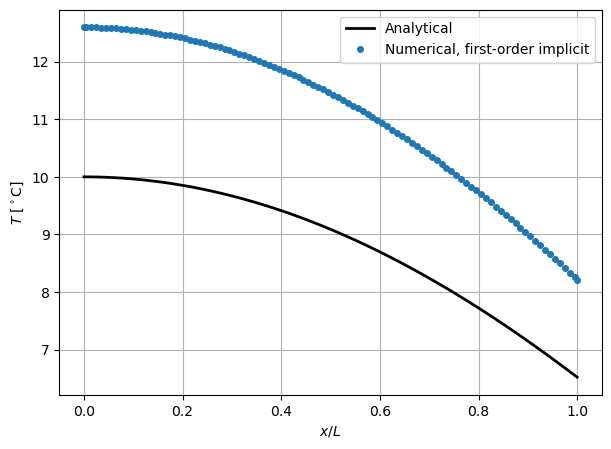

In [87]:
%matplotlib inline
T_exact_final = analytical_T(grid.xP, tau2)

plt.figure(figsize=(7, 5))
plt.plot(grid.xP, T_exact_final, "k-", linewidth=2, label="Analytical")
plt.plot(grid.xP, T, "o", markersize=4, label="Numerical, first-order implicit")

plt.xlabel(r"$x/L$")
plt.ylabel(r"$T$ [$^\circ$C]")
plt.grid(True)
plt.legend()
plt.show()

In [89]:
# Define the coefficients
coeffs = ScalarCoeffs(grid.ncv)

# Initial conditions
#T0 = 300

# Initialize field variable arrays
T = analytical_T(grid.xP, tau1)

# Define boundary conditions
west_bc = NeumannBc(T, grid, 0.0, BoundaryLocation.WEST)
east_bc = RobinBc(T, grid, h, k, To, BoundaryLocation.EAST)

# Apply boundary conditions
west_bc.apply()
east_bc.apply()

# Create list to store the solutions at each timestep
T_solns = [np.copy(T)]

# Define the surface convection model
#surfaceConvection = SurfaceConvectionModel(grid, T, ho, To)

# Loop through all timesteps
Told = np.copy(T)
Told2 = np.copy(T)

diffusion = DiffusionModel(grid, T, k, west_bc, east_bc)

time = tau1

for tStep in range(nTime):

    time += dt

    print("Timestep = {}; Time = {}".format(tStep + 1, time))

    if tStep == 0:
        # First timestep: use first-order implicit because T^{n-1} is unavailable
        Told[:] = T[:]

        transient = FirstOrderTransientModel(
            grid, T, Told, rho, cp, dt
        )

    else:
        # Second-order implicit:
        # Told  = T^n
        # Told2 = T^{n-1}
        Told2[:] = Told[:]
        Told[:] = T[:]

        transient = SecondOrderTransientModel(
            grid, T, Told, Told2, rho, cp, dt
        )

    for i in range(maxIter):

        coeffs.zero()

        coeffs = diffusion.add(coeffs)
        coeffs = transient.add(coeffs)

        maxResid = norm(coeffs.rP, np.inf)
        avgResid = np.mean(np.absolute(coeffs.rP))

        print("Iteration = {}; Max. Resid. = {}; Avg. Resid. = {}".format(
            i, maxResid, avgResid
        ))

        if maxResid < converged:
            break

        dT = solve(coeffs)

        T[1:-1] += dT

        west_bc.apply()
        east_bc.apply()

    T_solns.append(np.copy(T))

Timestep = 1; Time = 0.8047124999999999
Iteration = 0; Max. Resid. = 0.005920989565098013; Avg. Resid. = 0.005217763870926286
Iteration = 1; Max. Resid. = 1.428978463335895e-14; Avg. Resid. = 4.536935063748082e-15
Timestep = 2; Time = 1.1559249999999999
Iteration = 0; Max. Resid. = 0.007049400477361304; Avg. Resid. = 0.00621169710094012
Iteration = 1; Max. Resid. = 1.565327728547672e-14; Avg. Resid. = 4.73008784918072e-15
Timestep = 3; Time = 1.5071374999999998
Iteration = 0; Max. Resid. = 0.005661244807469294; Avg. Resid. = 0.004988337274997428
Iteration = 1; Max. Resid. = 1.5182299861749016e-14; Avg. Resid. = 4.299512135208516e-15
Timestep = 4; Time = 1.8583499999999997
Iteration = 0; Max. Resid. = 0.004430651594185232; Avg. Resid. = 0.0039039828677832587
Iteration = 1; Max. Resid. = 8.271161533457416e-15; Avg. Resid. = 2.9076394070237656e-15
Timestep = 5; Time = 2.2095624999999997
Iteration = 0; Max. Resid. = 0.003426591392507863; Avg. Resid. = 0.003019280742513042
Iteration = 1; Ma

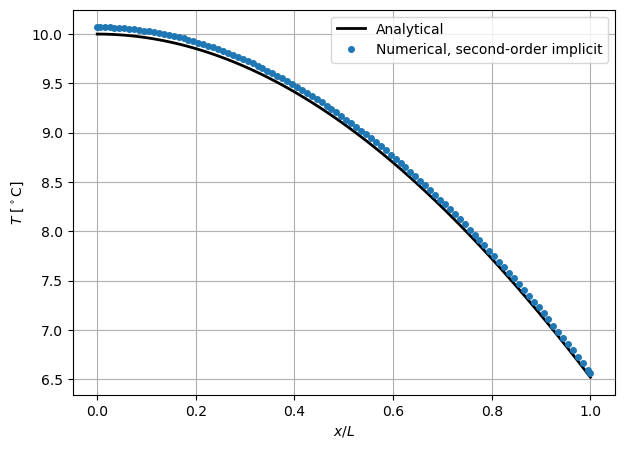

In [91]:
%matplotlib inline
T_exact_final = analytical_T(grid.xP, tau2)

plt.figure(figsize=(7, 5))
plt.plot(grid.xP, T_exact_final, "k-", linewidth=2, label="Analytical")
plt.plot(grid.xP, T, "o", markersize=4, label="Numerical, second-order implicit")

plt.xlabel(r"$x/L$")
plt.ylabel(r"$T$ [$^\circ$C]")
plt.grid(True)
plt.legend()
plt.show()